**Sep2026: runs without errors**

# Assess regrowth differences of glacier models for experiments that are colder than now

- I find it hard to think about an easy analaysis to do ...
- I was thinking about just looking into region 14 (South Asia W, as it is one with just a little bit of committed ice loss)... but I am actually not sure what to best assess, just looking into the steady-state would be very similar to what I did in Fig. 2
--> or should I repeat Fig. 2 with just above 80%?

--> actually I think that the best would be to check the evolution and judge from that? 
--> see timeseries evolutions for the time period 1850-1871....

Can I find out, if there are models that grow more than others? 
Do I need to search for experiment and regoiins where all or where the median model grows??? 

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import scipy
import os
import glob
import matplotlib.pyplot as plt
from datetime import date
import geopandas as gpd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
print(matplotlib.__version__)
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
# for plots within plots 
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


from help_functions import pal_models, model_order, d_reg_num_name, model_order_anonymous, compute_steady_state_yr,get_glob_temp_exp


3.5.3


In [2]:
# # these code lines above are equal to those at the beginning of 2_glacier_vs_climate_change
# download it here https://cluster.klima.uni-bremen.de/~lschuster/glacierMIP3_analysis/glacierMIP3_{DATE}_models_all_rgi_regions_sum_scaled.nc
# and change the path to your local path
DATE = 'Feb12_2024' #'Jun29' #'apr04' (has OGGM runaway effect of glaciers inside)
fill_option = 'repeat_last_101yrs'

path_merged_runs_scaled_extend = f'../data/GMIP3_reg_glacier_model_data/glacierMIP3_{DATE}_models_all_rgi_regions_sum_scaled_extended_{fill_option}.nc'
_ds_reg_models_extend = xr.open_dataset(path_merged_runs_scaled_extend)




In [3]:

# --> comes from isimip3b_postprocessing_analysis/isimip3b_postprocess_to_monthly.ipynb
pd_global_temp_exp = pd.read_csv('../data/climate_input_data/temp_ch_ipcc_ar6_isimip3b.csv', index_col = 0)

hue_order_anonymous = []

pal_models_l = []
hue_order = []
for m, p in zip(model_order, pal_models):
    if (m!='OGGM-VAS') and (m!='OGGM_v153'):
        hue_order.append(m)
        pal_models_l.append(p)
for m in hue_order:
    hue_order_anonymous.append(model_order_anonymous[m])
pal_models = pal_models_l

print(hue_order, hue_order_anonymous)
# select the right models:
pal_models = sns.color_palette(pal_models)

dict_model_col = {}
for c,m in zip(pal_models, hue_order):
    dict_model_col[m] = c
    
# select the right models

glac_models = hue_order

num_dict = {0:'(a)', 1:'(b)', 2:'(c)', 3:'(d)', 4: '(e)', 5:'(f)', 6:'(g)', 7:'(h)', 8:'(i)', 9:'(j)', 10:'(k)', 11:'(l)', 12:'(m)'} 



ind_t = pd_global_temp_exp.groupby(['gcm','period_scenario']).mean()['temp_ch_ipcc'].index
np.testing.assert_allclose(get_glob_temp_exp(region='global')['temp_ch_ipcc'].loc[ind_t].values,
                            pd_global_temp_exp.groupby(['gcm','period_scenario']).mean()['temp_ch_ipcc'].values, rtol=1e-5)
pd_global_temp_exp_m = get_glob_temp_exp(region='global')

####
glob_temp_ch = get_glob_temp_exp(region='global')['temp_ch_ipcc'].values


only_12_range = False
if only_12_range:
    colors_icci_l3 = ['#70B8FF', '#FABB00', '#F25100', '#D42300', '#B3001E', '#800040', '#550066', '#2B084D']
    cmap_icci_3 = LinearSegmentedColormap.from_list('bins_100', colors_icci_l3, N=1000)
    # IDEA --> Let's scale from 1.2 onwards
    scaler = MinMaxScaler()
    temp_ch_sel = np.arange(1.2,glob_temp_ch.max(),0.25)
    scaler.fit(temp_ch_sel.reshape(-1,1))
    cmap = cmap_icci_3
else:
    ## '#306BAF', '#1A488A', '#002966'
    ## '#4D8ED6',
    colors_full_temp_range = ['#002966', '#306BAF', '#70B8FF','#FABB00', '#F25100', '#D42300', '#B3001E', '#800040', '#550066', '#2B084D']
    cmap_full_temp_range = LinearSegmentedColormap.from_list('bins_100', colors_full_temp_range, N=1000)
    # IDEA --> Let's scale from the entire range onwards onwards
    scaler = MinMaxScaler()
    temp_ch_sel = np.arange(-0.36,glob_temp_ch.max(),0.25)# need to manually set the minimum to a lower value to have a light blue color at ~1.2°C
    scaler.fit(temp_ch_sel.reshape(-1,1))
    cmap = cmap_full_temp_range

norm = plt.Normalize(vmin=-0.36, vmax=glob_temp_ch.max()) # we need the -0.4 for the correct norm 
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
#sm.set_clim(glob_temp_ch.min(),glob_temp_ch.max())
# ok, both approaches work the same 
assert sm.cmap == cmap

t = 1.2
# just want to make sure that 1.2°C is this color here: '#70B8FF'
hex_color = '#70B8FF'
rgba_color = mcolors.to_rgba(hex_color)
c1=sm.cmap(scaler.transform(np.array(t).reshape(-1,1))).squeeze()
c2=cmap(scaler.transform(np.array(t).reshape(-1,1))).squeeze()
np.testing.assert_allclose(c1,c2)
np.testing.assert_allclose(c1,rgba_color)


# select the right models and option
approach = '_via_5yravg'
### todo: update paths to include wOGGM_v153 or exclude OGGM_v153
_ds_reg_yr_shift= xr.open_dataset(f'../data/GMIP3_reg_glacier_model_data/all_shifted_glacierMIP3_{DATE}_models_all_rgi_regions_sum_scaled_extended_{fill_option}{approach}.nc') #_wOGGM_v153.nc')
shift_years = True
if shift_years:
    add = '_shifted_to_2020'
    # we shift by maximum by +50 years, so like that there should always be values inside 
    ds_reg_yr_shift = _ds_reg_yr_shift.sel(year_after_2020=slice(0,4950))
    ds_reg_models = ds_reg_yr_shift.sel(model_author=glac_models)
    ds_reg_models_vol = ds_reg_models.volume_m3 #.isel(simulation_year=slice(0,2000)) #['relative volume change (in %)']
else:
    add = '_no_shift'
    ds_reg_models = _ds_reg_models_extend.sel(model_author=glac_models)
    ds_reg_models_vol = ds_reg_models.volume_m3 #.isel(simulation_year=slice(0,2000)) #['relative volume change (in %)']

# Let's take the median estimate from all glacier models for every RGI region and then do the sum:
ds_reg_models_vol = ds_reg_models_vol.stack(experiments=['gcm','period_scenario'])
ds_reg_models_vol = ds_reg_models_vol.assign_coords(temp_ch_ipcc = ('experiments',
                                                                      pd_global_temp_exp_m.loc[ds_reg_models_vol.experiments, # make sure thatwe use the same experiments
                                                                                             'temp_ch_ipcc']))
# need that to have bot volume_m3 and temp_ch_ipcc as variables
ds_reg_models_vol = ds_reg_models_vol.reset_coords()


['PyGEM-OGGM_v13', 'GloGEMflow', 'GloGEMflow3D', 'OGGM_v16', 'GLIMB', 'Kraaijenbrink', 'GO', 'CISM2'] ['model 1', 'model 2', 'model 3', 'model 4', 'model 5', 'model 6', 'model 7', 'model 8']


This is not really helpful... 

<AxesSubplot:xlabel='temp_ch_ipcc', ylabel='relative volume change (in %)'>

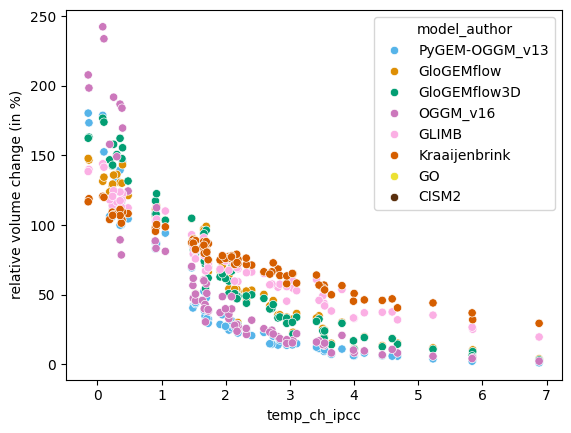

In [4]:

# let's select the region that is most "in" balance (or 13 similarly)
_ds_reg_yr_shift_14 = ds_reg_models_vol.sel(rgi_reg='14').dropna(dim='model_author',how='all')
_ds_reg_yr_shift_14['relative volume change (in %)'] = 100*_ds_reg_yr_shift_14['volume_m3']/_ds_reg_yr_shift_14['volume_m3'].sel(year_after_2020=0)#['volume_rel_2020_%']
_test = _ds_reg_yr_shift_14[['relative volume change (in %)','temp_ch_ipcc']].isel(year_after_2020=slice(-101,-1)).mean(dim='year_after_2020')
_test = _test.to_dataframe()
_test = _test.drop(columns=['gcm','period_scenario'])
_test = _test.reset_index()
sns.scatterplot(data=_test, x= 'temp_ch_ipcc', hue='model_author' , y='relative volume change (in %)',hue_order=hue_order,
                 palette=pal_models)

In [ ]:
rgi_reg='14'
plt.rc('font', size=24)  
_ds_reg_yr_shift_sel = ds_reg_models_vol.sel(rgi_reg=rgi_reg).dropna(dim='model_author',how='all')
'1851-1870_hist'
_ds_reg_yr_shift_sel['relative volume change (in %)'] = 100*_ds_reg_yr_shift_sel['volume_m3']/_ds_reg_yr_shift_sel['volume_m3'].sel(year_after_2020=0)#['volume_rel_2020_%']

_test = _ds_reg_yr_shift_sel[['relative volume change (in %)','temp_ch_ipcc']].to_dataframe()
_test = _test.drop(columns = ['gcm', 'period_scenario'])
_test = _test.reset_index()

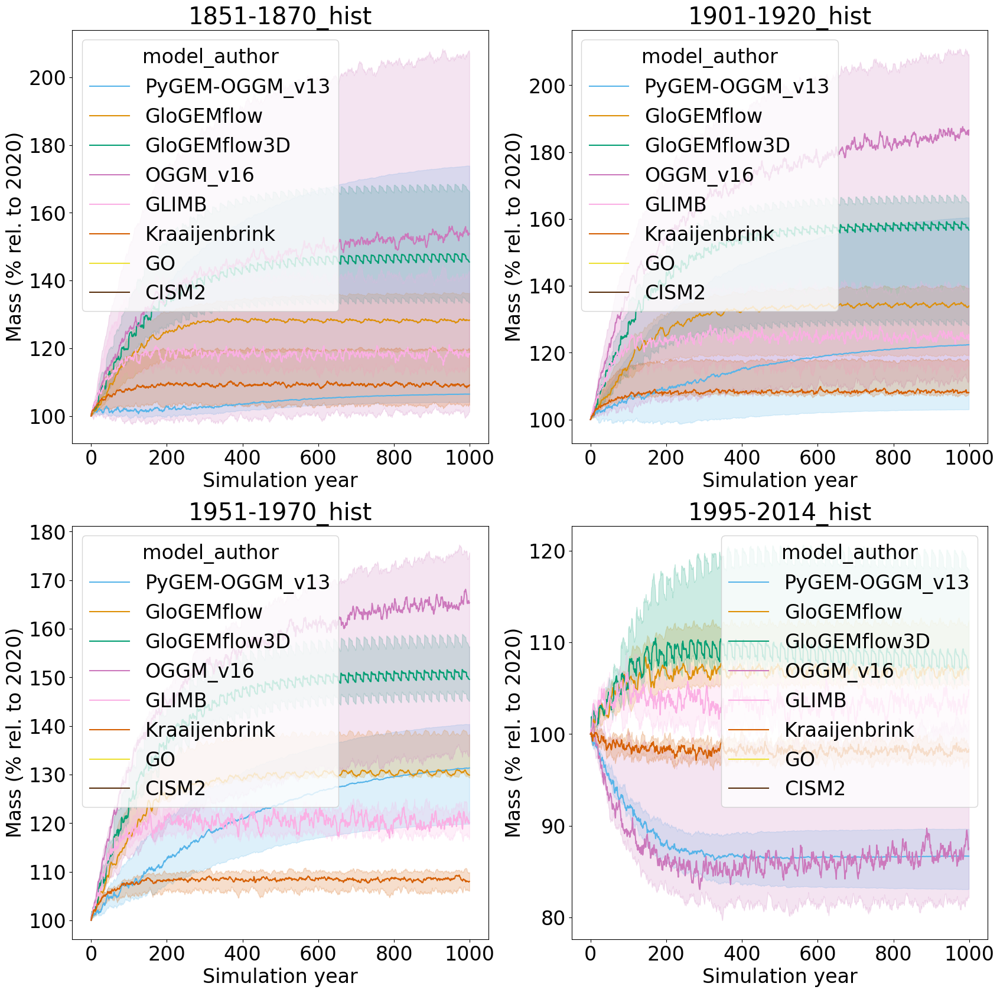

In [6]:

fig, axs= plt.subplots(2,2,figsize=(20,20))
axs = axs.flatten()
for j, ps in enumerate(['1851-1870_hist', '1901-1920_hist', '1951-1970_hist',
       '1995-2014_hist']):
    ax = axs[j]
    _test_sel = _test.loc[_test.period_scenario==ps]
    _test_sel = _test_sel.loc[_test.year_after_2020<1000]
    sns.lineplot(data=_test_sel, hue='model_author', x= 'year_after_2020',hue_order=hue_order,
                 palette=pal_models, y='relative volume change (in %)', estimator='median', errorbar=('pi',66) , ax = ax)
    ax.set_title(ps)
    ax.set_ylabel('Mass (% rel. to 2020)')
    ax.set_xlabel('Simulation year')

# now do the same with all RGI regions  

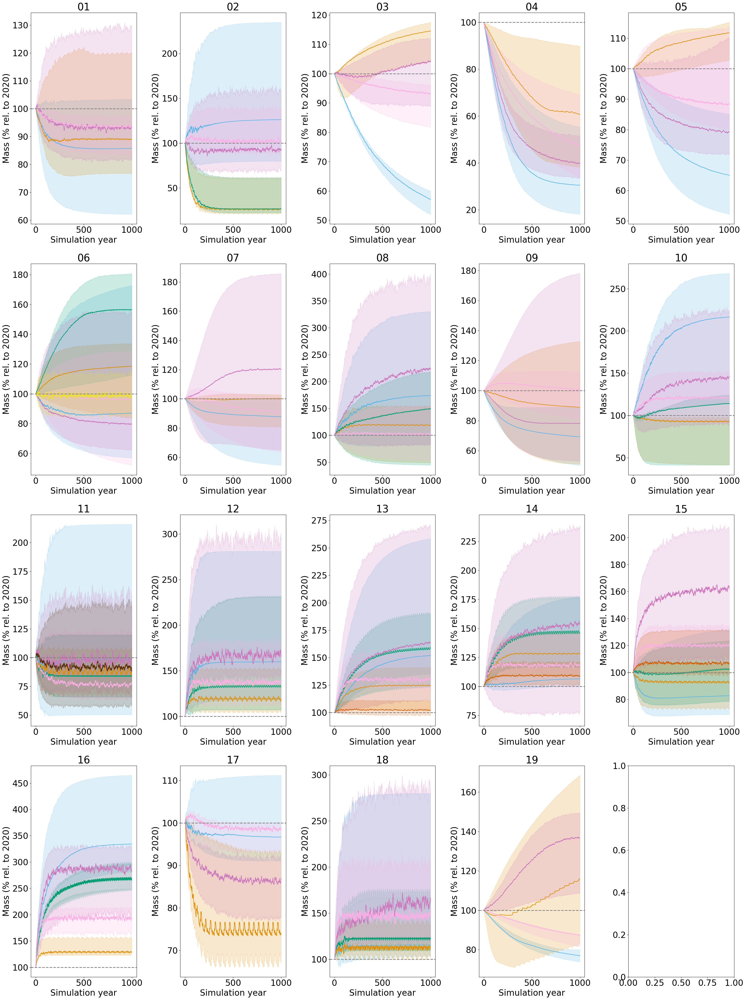

In [7]:
ps = '1851-1870_hist'
plt.rc('font', size=24)  

fig, axs= plt.subplots(4,5,figsize=(30,40))
axs = axs.flatten()
for j,rgi_reg in enumerate(ds_reg_models_vol.rgi_reg.values):
    ax = axs[j]
    _ds_reg_yr_shift_sel = ds_reg_models_vol.sel(rgi_reg=rgi_reg).dropna(dim='model_author',how='all')
    _ds_reg_yr_shift_sel['relative volume change (in %)'] = 100*_ds_reg_yr_shift_sel['volume_m3']/_ds_reg_yr_shift_sel['volume_m3'].sel(year_after_2020=0)#['volume_rel_2020_%']
    
    _test = _ds_reg_yr_shift_sel[['relative volume change (in %)','temp_ch_ipcc']].to_dataframe()
    _test = _test.drop(columns=['gcm','period_scenario'])
    _test = _test.reset_index()
    _test_sel = _test.loc[_test.period_scenario==ps]
    _test_sel = _test_sel.loc[_test.year_after_2020<1000]
    sns.lineplot(data=_test_sel, hue='model_author', x= 'year_after_2020',hue_order=hue_order,
                 palette=pal_models, y='relative volume change (in %)', estimator='median', errorbar=('pi',100) , ax = ax)
    ax.set_title(rgi_reg)
    ax.get_legend().remove()
    ax.axhline(100, ls='--',lw=2, color='grey') 
    ax.set_ylabel('Mass (% rel. to 2020)')
    ax.set_xlabel('Simulation year')
plt.tight_layout()

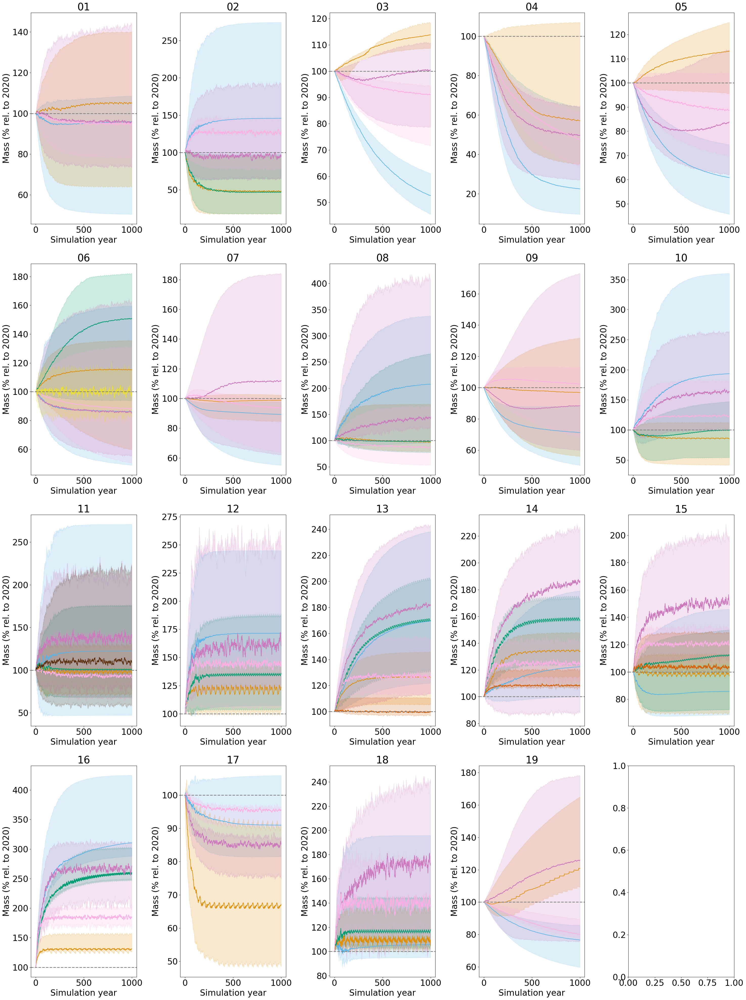

In [8]:
ps = '1901-1920_hist'
plt.rc('font', size=24)  

fig, axs= plt.subplots(4,5,figsize=(30,40))
axs = axs.flatten()
for j,rgi_reg in enumerate(ds_reg_models_vol.rgi_reg.values):
    ax = axs[j]
    _ds_reg_yr_shift_sel = ds_reg_models_vol.sel(rgi_reg=rgi_reg).dropna(dim='model_author',how='all')
    _ds_reg_yr_shift_sel['relative volume change (in %)'] = 100*_ds_reg_yr_shift_sel['volume_m3']/_ds_reg_yr_shift_sel['volume_m3'].sel(year_after_2020=0)#['volume_rel_2020_%']
    
    _test = _ds_reg_yr_shift_sel[['relative volume change (in %)','temp_ch_ipcc']].to_dataframe()
    _test = _test.drop(columns=['gcm','period_scenario'])
    _test = _test.reset_index()
    _test_sel = _test.loc[_test.period_scenario==ps]
    _test_sel = _test_sel.loc[_test.year_after_2020<1000]
    sns.lineplot(data=_test_sel, hue='model_author', x= 'year_after_2020',hue_order=hue_order,
                 palette=pal_models, y='relative volume change (in %)', estimator='median', errorbar=('pi',100) , ax = ax)
    ax.set_title(rgi_reg)
    ax.get_legend().remove()
    ax.axhline(100, ls='--',lw=2, color='grey') 
    ax.set_ylabel('Mass (% rel. to 2020)')
    ax.set_xlabel('Simulation year')
plt.tight_layout()

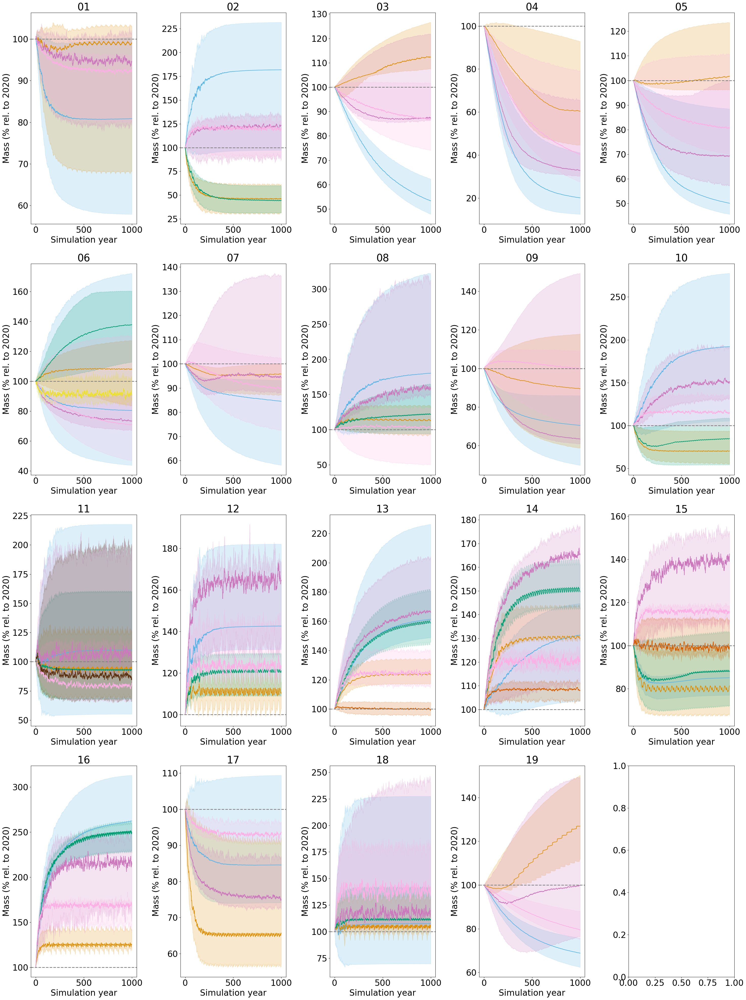

In [9]:
ps = '1951-1970_hist'
plt.rc('font', size=24)  

fig, axs= plt.subplots(4,5,figsize=(30,40))
axs = axs.flatten()
for j,rgi_reg in enumerate(ds_reg_models_vol.rgi_reg.values):
    ax = axs[j]
    _ds_reg_yr_shift_sel = ds_reg_models_vol.sel(rgi_reg=rgi_reg).dropna(dim='model_author',how='all')
    _ds_reg_yr_shift_sel['relative volume change (in %)'] = 100*_ds_reg_yr_shift_sel['volume_m3']/_ds_reg_yr_shift_sel['volume_m3'].sel(year_after_2020=0)#['volume_rel_2020_%']
    
    _test = _ds_reg_yr_shift_sel[['relative volume change (in %)','temp_ch_ipcc']].to_dataframe()
    _test = _test.drop(columns=['gcm','period_scenario'])
    _test = _test.reset_index()
    _test_sel = _test.loc[_test.period_scenario==ps]
    _test_sel = _test_sel.loc[_test.year_after_2020<1000]
    sns.lineplot(data=_test_sel, hue='model_author', x= 'year_after_2020',hue_order=hue_order,
                 palette=pal_models, y='relative volume change (in %)', estimator='median', errorbar=('pi',100) , ax = ax)
    ax.set_title(rgi_reg)
    ax.get_legend().remove()
    ax.axhline(100, ls='--',lw=2, color='grey') 
    ax.set_ylabel('Mass (% rel. to 2020)')
    ax.set_xlabel('Simulation year')

plt.tight_layout()

**just for comparison, climate scenario without growing**

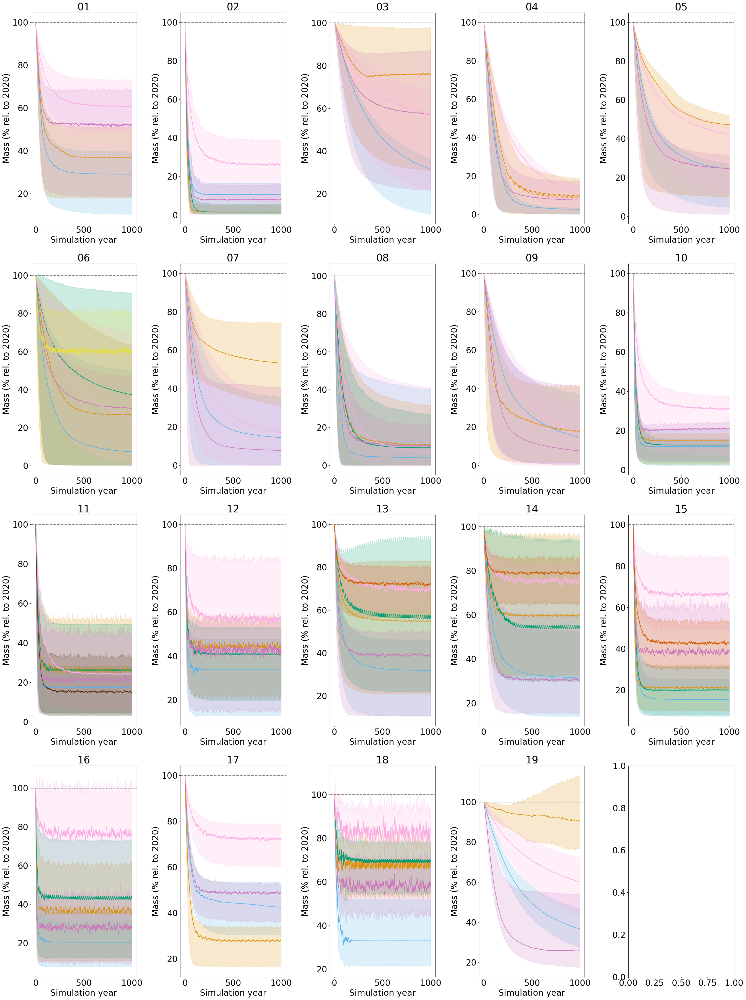

In [10]:
ps = '2081-2100_ssp126'
plt.rc('font', size=24)  

fig, axs= plt.subplots(4,5,figsize=(30,40))
axs = axs.flatten()
for j,rgi_reg in enumerate(ds_reg_models_vol.rgi_reg.values):
    ax = axs[j]
    _ds_reg_yr_shift_sel = ds_reg_models_vol.sel(rgi_reg=rgi_reg).dropna(dim='model_author',how='all')
    _ds_reg_yr_shift_sel['relative volume change (in %)'] = 100*_ds_reg_yr_shift_sel['volume_m3']/_ds_reg_yr_shift_sel['volume_m3'].sel(year_after_2020=0)#['volume_rel_2020_%']
    
    _test = _ds_reg_yr_shift_sel[['relative volume change (in %)','temp_ch_ipcc']].to_dataframe()
    _test = _test.drop(columns=['gcm','period_scenario'])
    _test = _test.reset_index()
    _test_sel = _test.loc[_test.period_scenario==ps]
    _test_sel = _test_sel.loc[_test.year_after_2020<1000]
    sns.lineplot(data=_test_sel, hue='model_author', x= 'year_after_2020',hue_order=hue_order,
                 palette=pal_models, y='relative volume change (in %)', estimator='median', errorbar=('pi',100) , ax = ax)
    ax.set_title(rgi_reg)
    ax.get_legend().remove()
    ax.axhline(100, ls='--',lw=2, color='grey') 
    ax.set_ylabel('Mass (% rel. to 2020)')
    ax.set_xlabel('Simulation year')
plt.tight_layout()

**Are there specific glacier region growth patterns visible???**
- Clear pattern between GloGEMflow (orange) and GloGEMflow3D (green)?
    - GLoGEMflow3D grows much more than GloGEMflow in all regions that grow for 1851-1870... : 6, 8, 10, 12, 13, 14, 15, 16, 18 (similarly true for '1901-1920_hist' and for '1951-1970_hist')
    - extreme cases are 06 and 16... why is this going on ??? 
- all models grow, though at very different rates..., and the differences in the climate model choice are also different between glacier models (similarly analysed in PartB_3_glacier_model_differences using the difeence to the reference)
    - for example, OGGM model spread from climate model choice is huge in Subantarctic and Antarctc Islands under 1951-1970_hist, ... though, the model spread is really small for PyGEM-oGGM or GLIMB... but this can change for other regions and experiments ... 
- I would say there is not a clear pattern, though in general, GLIMB tends to respond the fastest ... (but also not always... ), OGGM grows often a lot, those regions where it grows less than other glacier models may be those regions with a lot of tidewater glaciers... and where other models (such as PyGEM-OGGM) used calving parameterisations ... 